## Langgraph

In [1]:
# It is a library that is used to design the flow (a sort of pipeline)

In [2]:
# Langchain Runnable - No Reasoning required - Pipeline

In [3]:
# Agents 

# We give the tools to an agent (LLM) and let it handle the tools and final response as per the query

# create_agent()

In [4]:
# Agent (LLM) -> Probablistic Models (Minimal control of the flow, LLM decides the whole flow)
# Possibility, an agent might mistake / fail in some cases

# Tool-A, Tool-B, Tool-C -> Response

In [5]:
# Langgraph (graph)- Deterministic

#   - We design the flow
#   - We can do validation
#   - We can define/decide when to retry and when to stop

# Using graph we can create the flow where we may have tools/agents

# start- query - refine-query - tool - if retry or generate

### Components of a Graph

In [6]:
# State -> Data Flow (Memory)
# - It is a dictionary that holds some data (key:value)

# Nodes-> Functions (Data/State modifiers)
# - As the data (state) moves through the nodes, the data changes/modifies

# Edges-> Graph connectors
# - Edeges decides the flow how the data will move through the nodes

# Conditional Ededges -> Decision Makers / Connectors
# When we have to decide the direction of the flow then we use conditional edges

In [7]:
# Nodes=Tools (Incorrect)
# Nodes/Tools = Function

In [8]:
# Tool / Agent / Graph / Agentic workflow

## Agent using Langgraph

In [14]:
import os
from typing import TypedDict
from datetime import datetime
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent

### Tools

In [22]:
def calculator_tool(query: str) -> str:
    return str(eval(query))

In [23]:
def word_counter_tool(text: str) -> str:
    return len(text.split())

In [24]:
def current_time_tool(_:str = '') -> str:
    return datetime.now().strftime('%Y-%m-%d %H:%M:%S')

### LLM

In [16]:
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0, api_key=os.getenv('OPENAI_SECRET_KEY'))
llm

ChatOpenAI(profile={'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000027728F535D0>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000027729433B90>, root_client=<openai.OpenAI object at 0x0000027728F53350>, root_async_client=<openai.AsyncOpenAI object at 0x0000027728F1BC50>, model_name='gpt-4o-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), stream_usage=True)

### State (Memory)

In [18]:
class AgentState(TypedDict):
    query: str
    tool: str
    tool_input: str
    result: str
    
AgentState

__main__.AgentState

### Nodes

In [19]:
# Router Node

def router_node(state):
    query = state['query']
    prompt=f"""Decide which tool to be used for the given query:
Tools:
    - calculator
    - word_counter
    - current_time
Query:
{query}

Return only the tool name"""

    result=llm.invoke(prompt).content.strip().lower()

    return {'tool':result}

router_node

<function __main__.router_node(state)>

In [ ]:
# query cleaning - regex / llm

def format_math_node(state):
    query=state['query']

    prompt=f"""Extract only the mathematical expression from the given query so that it can be computed using a Python function.
    
    Query:
    {query}"""

    result = llm.invoke(prompt).content.strip()

    return {'tool_input':result}

In [25]:
def calculator_node(state):
    query = state['tool_input']
    result = calculator_tool(query)
    
    return {result}

In [26]:
def format_word_counter_node(state):
    return {'tool_input': state['query']}

In [27]:
def word_counter_node(state):
    query = state['tool_input']
    result = word_counter_tool(query)
    
    return {result}

In [28]:
def format_time_node(state):
    return {'tool_input': ''}

In [29]:
def current_time_node(state):
    query = state['tool_input']
    result = current_time_tool(query)
    
    return {result}

### Add Nodes

In [34]:
graph = StateGraph(AgentState)
graph

In [35]:
graph.add_node('router_n', router_node)
graph.add_node('calculator_n', calculator_node)
graph.add_node('word_counter_n', word_counter_node)
graph.add_node('current_time_n', current_time_node)

### Add Formatter Nodes

In [36]:
graph.add_node('format_math', format_math_node)
graph.add_node('format_word_counter', format_word_counter_node)
graph.add_node('format_time', format_time_node)

### Flow

In [38]:
# router node sets the tool name based on query using the llm 
# router helper returns the dictionary with the tool name and formatter mappings
# the formatter gets called based on the tool returned by the helper
# then, the actual node will be called

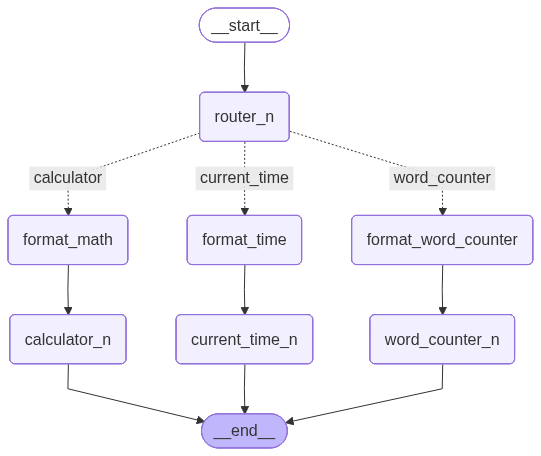

In [37]:
def router_helper(state):
    return state['tool']

graph.add_conditional_edges(
    'router_n',
    router_helper,
    {
        'calculator': 'format_math',
        'word_counter': 'format_word_counter',
        'current_time': 'format_time',
    }
)

graph.add_edge('format_math', 'calculator_n')
graph.add_edge('format_word_counter', 'word_counter_n')
graph.add_edge('format_time', 'current_time_n')

graph.add_edge('calculator_n', END)
graph.add_edge('word_counter_n', END)
graph.add_edge('current_time_n', END)

graph.set_entry_point('router_n')

app = graph.compile()
app